## Section A — Concept Application

### Question 1

The mean is misleading because the delivery times contain a few extreme values above 90 minutes. These unusually large values pull the mean upward, so it becomes higher than the delivery time experienced by most customers.

The median is a better measure because it is less affected by extreme values. Since the mean is greater than the median, the distribution is positively skewed or right-skewed. The distribution has most observations around 25–30 minutes with a long tail extending toward higher delivery times.

### Question 2

Given:

Prior probability of fraud = 0.05
Probability of flagging a fraudulent order = 0.90
Probability of a legitimate order = 0.95
Probability of incorrectly flagging a legitimate order = 0.08

Using Bayes' theorem:

P(Fraud | Flagged) = [P(Flagged | Fraud) × P(Fraud)] / [P(Flagged | Fraud) × P(Fraud) + P(Flagged | Legitimate) × P(Legitimate)]

= (0.90 × 0.05) / [(0.90 × 0.05) + (0.08 × 0.95)]

= 0.045 / 0.121

= 0.3719

Therefore, the probability that a flagged order is genuinely fraudulent is approximately 37.19%.

The result may surprise a non-technical stakeholder because the model detects 90% of fraudulent orders, but fraud is uncommon overall and legitimate orders can also be incorrectly flagged.

### Question 3

The first preprocessing problem is the missing values in restaurant_rating. Missing values should be handled using imputation, such as replacing them with the mean restaurant rating.

The second problem is that payment_method and cuisine_type are categorical text variables. They should be converted into numerical variables using one-hot encoding.

Unresolved missing values can prevent a model from processing the data correctly, while unprocessed categorical values cannot be directly used by most machine learning algorithms. Inconsistent preprocessing can also cause the model to learn patterns that do not generalise well to unseen test data.

### Question 4

Overall accuracy is misleading because only 1% of the orders are fraudulent. A model could achieve very high accuracy by mostly predicting that orders are legitimate while still missing many fraudulent orders.

The finance team's main concern is undetected fraud, so recall is the appropriate metric.

Recall = TP / (TP + FN)

Model B correctly identifies 420 of the 500 fraudulent orders.

Recall = 420 / 500 = 0.84 = 84%

Therefore, Model B should be adopted because it identifies 84% of fraudulent orders and better addresses the business objective of reducing undetected fraud.

### Question 5

K-Means is suitable when customers naturally form a known or estimable number of groups with similar density. DBSCAN is useful when clusters have arbitrary shapes and when many outliers or noise points are present.

K-Means is the better choice here because the customers naturally form 3–4 groups, the groups have similar density, and there are very few genuine outliers.

One limitation is that K-Means requires the number of clusters to be selected and works best when the clusters are relatively compact. The marketing team should therefore understand that the resulting groups depend on the selected value of k and the features used.

### Question 6

PCA is useful before K-Means because the dataset contains 35 features and many of them are highly correlated. PCA transforms the original features into a smaller set of principal components that retain as much of the important variance as possible.

The first principal component captures the greatest amount of variance, the second captures the next greatest amount, and so on. This can make K-Means faster, reduce redundancy and make the results easier to visualise.

The trade-off is between retaining information and reducing dimensionality. Keeping more components preserves more variance but provides less dimensionality reduction. Keeping fewer components makes the model simpler and faster but may lose information. The explained variance ratio can be used to select enough components to retain an acceptable percentage of the total variance.

## Section B — Practical Coding Tasks

### Task 1 — Delivery Time Statistical Profiler

In [2]:
import statistics

delivery_times = [25, 28, 30, 27, 32, 90, 60, 88, 35, 78, 30, 105, 33, 82, 95, 110]

mean_value = statistics.mean(delivery_times)
median_value = statistics.median(delivery_times)
mode_value = statistics.mode(delivery_times)
variance_value = statistics.variance(delivery_times)
std_value = statistics.stdev(delivery_times)

print("=" * 42)
print("DELIVERY TIME STATISTICAL REPORT")
print("=" * 42)
print(f"Mean               : {mean_value:.2f}")
print(f"Median             : {median_value:.2f}")
print(f"Mode               : {mode_value:.2f}")
print(f"Variance           : {variance_value:.2f}")
print(f"Standard Deviation : {std_value:.2f}")
print()

if mean_value > median_value:
    print("Conclusion         : The distribution is right-skewed.")
elif mean_value < median_value:
    print("Conclusion         : The distribution is left-skewed.")
else:
    print("Conclusion         : The distribution is approximately symmetrical.")

DELIVERY TIME STATISTICAL REPORT
Mean               : 59.25
Median             : 47.50
Mode               : 30.00
Variance           : 1033.93
Standard Deviation : 32.15

Conclusion         : The distribution is right-skewed.


### Task 2 — Order Dataset Preprocessor

In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame({
    "order_id": range(1001, 1013),
    "restaurant_rating": [4.2, 3.8, None, 
                          4.5, 3.5, None,
                          4.0, 4.7, 3.9,
                          4.3, 3.6, 4.8],
    "payment_method": ["Cash", "Card", "Wallet",
                       "Card", "Cash", "Wallet",
                       "Card", "Cash", "Wallet",
                       "Card", "Cash", "Wallet"],
    "cuisine_type": ["Indian", "Chinese", "Italian",
                     "Fast Food", "Indian", "Chinese",
                     "Italian", "Fast Food", "Indian",
                     "Chinese", "Italian", "Fast Food"],
    "order_value": [250.0, 480.0, 320.0,
                    650.0, 180.0, 520.0,
                    410.0, 720.0, 290.0,
                    560.0, 350.0, 800.0]
})

df["restaurant_rating"] = df["restaurant_rating"].fillna(df["restaurant_rating"].mean())

print("Missing values after imputation:")
print(df.isnull().sum())

df = pd.get_dummies(df, columns=["payment_method", "cuisine_type"], dtype=int)

scaler = MinMaxScaler()
df[["restaurant_rating", "order_value"]] = scaler.fit_transform(df[["restaurant_rating", "order_value"]])

print()
print("Final Preprocessed DataFrame:")
print(df.to_string(index=False))

Missing values after imputation:
order_id             0
restaurant_rating    0
payment_method       0
cuisine_type         0
order_value          0
dtype: int64

Final Preprocessed DataFrame:
 order_id  restaurant_rating  order_value  payment_method_Card  payment_method_Cash  payment_method_Wallet  cuisine_type_Chinese  cuisine_type_Fast Food  cuisine_type_Indian  cuisine_type_Italian
     1001           0.538462     0.112903                    0                    1                      0                     0                       0                    1                     0
     1002           0.230769     0.483871                    1                    0                      0                     1                       0                    0                     0
     1003           0.484615     0.225806                    0                    0                      1                     0                       0                    0                     1
     1004           0.76

### Task 3 — Order Cancellation Classifier

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

n = 150

order_value = np.round(np.random.uniform(100, 1000, n), 2)
delivery_distance_km = np.round(np.random.uniform(1, 20, n), 2)
hour_of_day = np.random.randint(0, 24, n)
restaurant_rating = np.round(np.random.uniform(2.5, 5.0, n), 2)

score = (
    (delivery_distance_km > 14).astype(int)
    + (hour_of_day >= 20).astype(int)
    + (restaurant_value := (order_value > 700)).astype(int)
    + (restaurant_rating < 3.5).astype(int)
)

rank = np.argsort(score + np.random.uniform(0, 1, n))
cancelled = np.zeros(n, dtype=int)
cancelled[rank[-34:]] = 1

df = pd.DataFrame({
    "order_value": order_value,
    "delivery_distance_km": delivery_distance_km,
    "hour_of_day": hour_of_day,
    "restaurant_rating": restaurant_rating,
    "cancelled": cancelled
})

X = df.drop("cancelled", axis=1)
y = df["cancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=["Not Cancelled", "Cancelled"]))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(pd.DataFrame(
    cm,
    index=["Actual Not Cancelled", "Actual Cancelled"],
    columns=["Predicted Not Cancelled", "Predicted Cancelled"]
))

print()
print(f"TN: {cm[0, 0]}")
print(f"FP: {cm[0, 1]}")
print(f"FN: {cm[1, 0]}")
print(f"TP: {cm[1, 1]}")

Classification Report
               precision    recall  f1-score   support

Not Cancelled       0.80      0.87      0.83        23
    Cancelled       0.40      0.29      0.33         7

     accuracy                           0.73        30
    macro avg       0.60      0.58      0.58        30
 weighted avg       0.71      0.73      0.72        30

Confusion Matrix
                      Predicted Not Cancelled  Predicted Cancelled
Actual Not Cancelled                       20                    3
Actual Cancelled                            5                    2

TN: 20
FP: 3
FN: 5
TP: 2


### Task 4 — Customer Segmentation with K-Means and PCA

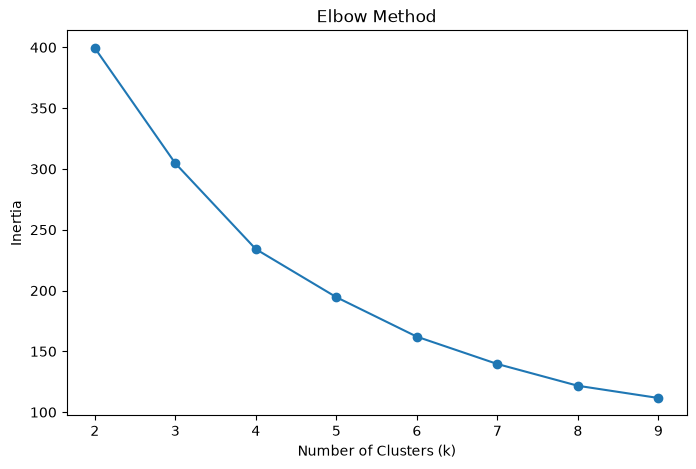

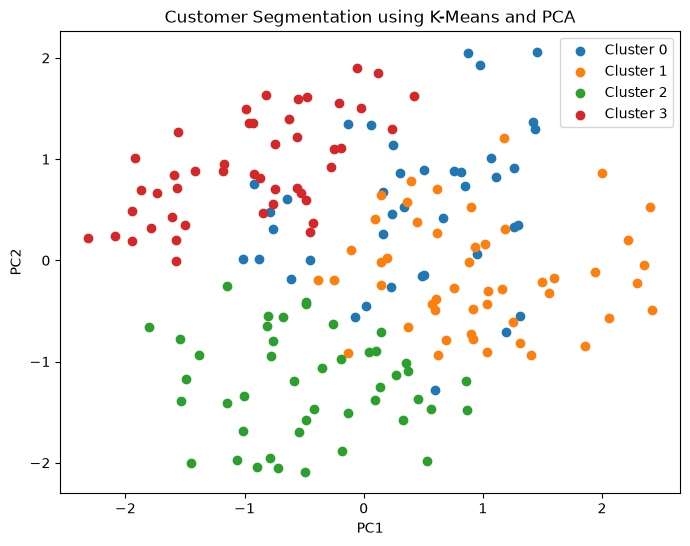

Cluster Counts
cluster
0    40
1    49
2    45
3    46
Name: count, dtype: int64

Cluster Centroids
   monthly_orders  avg_order_value  avg_delivery_rating
0           21.00          1023.56                 3.63
1            8.29           707.44                 4.41
2            8.64           575.18                 3.01
3           25.83           459.33                 3.86


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(42)

n_customers = 180

customers = pd.DataFrame({
    "monthly_orders": np.random.randint(1, 31, n_customers),
    "avg_order_value": np.round(np.random.uniform(150, 1200, n_customers), 2),
    "avg_delivery_rating": np.round(np.random.uniform(2.5, 5.0, n_customers), 2)
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customers)

inertias = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 10))
plt.show()

optimal_k = 4

final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customers["cluster"] = final_model.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for cluster in sorted(customers["cluster"].unique()):
    mask = customers["cluster"] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using K-Means and PCA")
plt.legend()
plt.show()

print("Cluster Counts")
print(customers["cluster"].value_counts().sort_index())

centroids_original = scaler.inverse_transform(final_model.cluster_centers_)
centroid_df = pd.DataFrame(
    centroids_original,
    columns=["monthly_orders", "avg_order_value", "avg_delivery_rating"]
)

print()
print("Cluster Centroids")
print(centroid_df.round(2))

## Section C — Mini Capstone Project

In [ ]:
import numpy as np
import pandas as pd
from statistics import mean, median, stdev
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)

n = 180

customers = pd.DataFrame({
    "monthly_orders": np.random.randint(1, 31, n),
    "avg_order_value": np.round(np.random.uniform(150, 1200, n), 2),
    "avg_delivery_rating": np.round(np.random.uniform(2.5, 5.0, n), 2)
})

orders = pd.DataFrame({
    "order_value": np.round(np.random.uniform(100, 1000, n), 2),
    "delivery_distance_km": np.round(np.random.uniform(1, 20, n), 2),
    "restaurant_rating": np.round(np.random.uniform(2.5, 5.0, n), 2)
})

risk_score = (
    (orders["delivery_distance_km"] > 14).astype(int)
    + (orders["order_value"] > 700).astype(int)
    + (orders["restaurant_rating"] < 3.5).astype(int)
)

orders["cancelled"] = 0
highest_risk = np.argsort(risk_score.to_numpy() + np.random.random(n))[-34:]
orders.loc[highest_risk, "cancelled"] = 1

X = orders[["order_value", "delivery_distance_km", "restaurant_rating"]]
y = orders["cancelled"]

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X, y)

scaler = StandardScaler()
customer_features = customers[["monthly_orders", "avg_order_value", "avg_delivery_rating"]]
customer_scaled = scaler.fit_transform(customer_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customers["cluster"] = kmeans.fit_predict(customer_scaled)

def statistical_summary():
    print()
    print("=" * 50)
    print("STATISTICAL SUMMARY")
    print("=" * 50)

    for column in ["order_value", "delivery_distance_km"]:
        values = orders[column].tolist()
        avg = mean(values)
        med = median(values)
        sd = stdev(values)

        if avg > med:
            skew = "Right-skewed"
        elif avg < med:
            skew = "Left-skewed"
        else:
            skew = "Approximately symmetrical"

        print(f"\n{column}")
        print(f"Mean       : {avg:.2f}")
        print(f"Median     : {med:.2f}")
        print(f"Std Dev    : {sd:.2f}")
        print(f"Skewness   : {skew}")

def predict_risk():
    print()
    print("=" * 50)
    print("CANCELLATION RISK PREDICTION")
    print("=" * 50)

    try:
        order_value = float(input("Enter order value: "))
        distance = float(input("Enter delivery distance in km: "))
        rating = float(input("Enter restaurant rating: "))

        if order_value <= 0:
            raise ValueError("Order value must be greater than 0.")
        if distance <= 0:
            raise ValueError("Delivery distance must be greater than 0.")
        if not 1 <= rating <= 5:
            raise ValueError("Restaurant rating must be between 1 and 5.")

        sample = pd.DataFrame({
            "order_value": [order_value],
            "delivery_distance_km": [distance],
            "restaurant_rating": [rating]
        })

        prediction = model.predict(sample)[0]
        probability = model.predict_proba(sample)[0][1]

        if prediction == 1:
            result = "High Cancellation Risk"
        else:
            result = "Low Cancellation Risk"

        print(f"\nPrediction  : {result}")
        print(f"Probability : {probability * 100:.2f}%")

    except ValueError as e:
        print(f"Invalid input: {e}")

def segmentation():
    print()
    print("=" * 50)
    print("CUSTOMER SEGMENTATION")
    print("=" * 50)

    counts = customers["cluster"].value_counts().sort_index()

    for cluster, count in counts.items():
        print(f"Cluster {cluster}: {count} customers")

    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    print()
    print("Cluster Centroids")

    for i, centroid in enumerate(centroids):
        print(
            f"Cluster {i}: "
            f"Monthly Orders = {centroid[0]:.2f}, "
            f"Average Order Value = {centroid[1]:.2f}, "
            f"Average Rating = {centroid[2]:.2f}"
        )

while True:
    print()
    print("=" * 50)
    print("FOOD DELIVERY CUSTOMER INTELLIGENCE")
    print("=" * 50)
    print("1. View Statistical Summary")
    print("2. Predict Cancellation Risk for a New Order")
    print("3. Run Customer Segmentation")
    print("4. Exit")

    choice = input("Enter your choice: ")

    if choice == "1":
        statistical_summary()
    elif choice == "2":
        predict_risk()
    elif choice == "3":
        segmentation()
    elif choice == "4":
        print("Program ended.")
        break
    else:
        print("Invalid choice. Please select 1, 2, 3 or 4.")


FOOD DELIVERY CUSTOMER INTELLIGENCE
1. View Statistical Summary
2. Predict Cancellation Risk for a New Order
3. Run Customer Segmentation
4. Exit


Enter your choice:  2



CANCELLATION RISK PREDICTION


Enter order value:  2
Enter delivery distance in km:  25
Enter restaurant rating:  3



Prediction  : Low Cancellation Risk
Probability : 34.00%

FOOD DELIVERY CUSTOMER INTELLIGENCE
1. View Statistical Summary
2. Predict Cancellation Risk for a New Order
3. Run Customer Segmentation
4. Exit


...

Enter order value:  220
Enter delivery distance in km:  9
Enter restaurant rating:  2.5



Prediction  : Low Cancellation Risk
Probability : 29.00%

FOOD DELIVERY CUSTOMER INTELLIGENCE
1. View Statistical Summary
2. Predict Cancellation Risk for a New Order
3. Run Customer Segmentation
4. Exit


Enter your choice:  2



CANCELLATION RISK PREDICTION


Enter order value:  4
Enter delivery distance in km:  100


## Section D — AI-Augmented Learning

### AI Prompt

Create a Python program for a food delivery customer dataset with at least three numeric features. Apply StandardScaler, use the Elbow Method to determine the optimal number of K-Means clusters, plot the inertia curve, print each cluster's centroid values and customer count, and visualise the final clusters in 2D using PCA with PC1 and PC2 axis labels and a legend.

### Testing and Debugging Note

The original solution needed to be checked for preprocessing and reproducibility issues. StandardScaler was applied before K-Means so that features with different scales would not dominate the clustering. A fixed random_state was used in K-Means so that the results are reproducible. The PCA plot was also labelled with PC1 and PC2 to make the visualisation clear.